In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

## Data exploration

In [2]:
df = pd.read_csv("datahouse.csv")
df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0


In [3]:
df.shape

(226916, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226916 entries, 0 to 226915
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                226916 non-null  object 
 1   town                 226916 non-null  object 
 2   flat_type            226916 non-null  object 
 3   block                226916 non-null  object 
 4   street_name          226916 non-null  object 
 5   storey_range         226916 non-null  object 
 6   floor_area_sqm       226916 non-null  float64
 7   flat_model           226916 non-null  object 
 8   lease_commence_date  226916 non-null  int64  
 9   remaining_lease      226916 non-null  object 
 10  resale_price         226916 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 19.0+ MB


In [5]:
df.describe()

,floor_area_sqm,lease_commence_date,resale_price
count,226916.000000,226916.000000,2.269160e+05
mean,96.737560,1996.478538,5.272604e+05
std,24.018309,14.322098,1.880114e+05
min,31.000000,1966.000000,1.400000e+05
25%,81.000000,1985.000000,3.880000e+05
50%,93.000000,1997.000000,4.958880e+05
75%,112.000000,2012.000000,6.328880e+05
max,366.700000,2021.000000,1.700000e+06


<Axes: xlabel='town'>

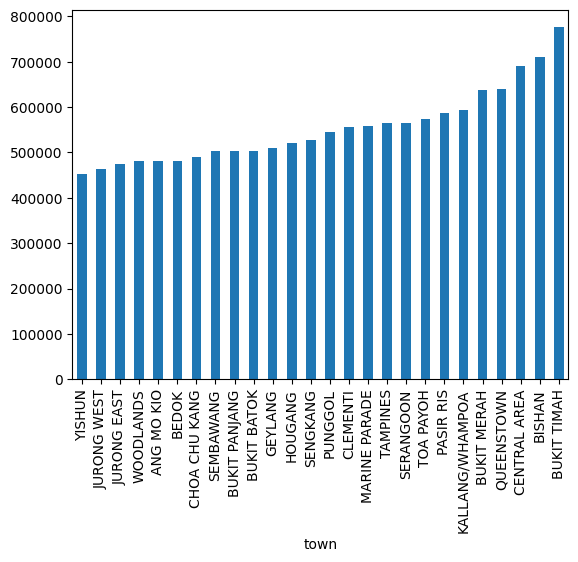

In [6]:
df.groupby("town")["resale_price"].mean().sort_values().plot(kind="bar")

## Converting categorical to numerical 

In [7]:
df["month_numeric"] = df["month"].str.split("-").apply(lambda x: int(x[0]) + (int(x[1])-1)/12)

storey_order = ["01 TO 03","04 TO 06","07 TO 09","10 TO 12",
                "13 TO 15","16 TO 18","19 TO 21","22 TO 24",
                "25 TO 27","28 TO 30","31 TO 33","34 TO 36",
                "37 TO 39","40 TO 42","43 TO 45","46 TO 48"]
df["storey_level"] = df["storey_range"].map({val: idx+1 for idx, val in enumerate(storey_order)})

In [8]:
flat_type_mapping = {"1 ROOM":1, "2 ROOM":2, "3 ROOM":3, "4 ROOM":4,
                     "5 ROOM":5, "EXECUTIVE":6, "MULTI-GENERATION":7}
df["flat_type_numeric"] = df["flat_type"].map(flat_type_mapping)

In [9]:
import re

def lease_to_months(x):
    years = int(re.search(r'(\d+)\s*year', x).group(1)) if re.search(r'(\d+)\s*year', x) else 0
    months = int(re.search(r'(\d+)\s*month', x).group(1)) if re.search(r'(\d+)\s*month', x) else 0
    return years*12 + months

df["remaining_lease_months"] = df["remaining_lease"].apply(lease_to_months)

In [10]:
df = df.drop(columns=["month","storey_range","flat_type","remaining_lease","block","street_name"])
df = df.dropna()

## OHE

In [11]:
df = pd.get_dummies(df, columns=["town", "flat_model"], drop_first=False)

## Separate X and Y

In [12]:
X = df.drop(columns=["resale_price", "lease_commence_date"])
y = df["resale_price"]

## Train-test split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Standardise numeric features 

In [14]:
numeric_cols = ["month_numeric","storey_level","flat_type_numeric","floor_area_sqm","remaining_lease_months"]
scaler = StandardScaler()

# Fit and Transform Training
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Transform Testing (Using the Mean/Std from Training)
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [15]:
X.head()

,floor_area_sqm,month_numeric,storey_level,flat_type_numeric,remaining_lease_months,town_ANG MO KIO,town_BEDOK,town_BISHAN,town_BUKIT BATOK,town_BUKIT MERAH,...,flat_model_Multi Generation,flat_model_New Generation,flat_model_Premium Apartment,flat_model_Premium Apartment Loft,flat_model_Premium Maisonette,flat_model_Simplified,flat_model_Standard,flat_model_Terrace,flat_model_Type S1,flat_model_Type S2
0,44.0,2017.0,4.0,2,736,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,67.0,2017.0,1.0,3,727,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
2,67.0,2017.0,1.0,3,749,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3,68.0,2017.0,2.0,3,745,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,67.0,2017.0,1.0,3,749,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [16]:
# Check the order of columns the scaler actually 'saw'
print(scaler.feature_names_in_)

['month_numeric' 'storey_level' 'flat_type_numeric' 'floor_area_sqm'
 'remaining_lease_months']


## Training Linear Regression

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
import joblib

# 1. Save the model
joblib.dump(model, 'house_modelv4.pkl')

# 2. Save the scaler
joblib.dump(scaler, 'scalerv4.pkl')

all_features = X.columns.tolist()

# Save it to a file
joblib.dump(all_features, 'model_columnsv4.pkl')

['model_columnsv4.pkl']

## Absolute coefficient

In [19]:
coef_abs = pd.Series(np.abs(model.coef_), index=X_train.columns)

## Aggregating OHE features

In [20]:
town_cols = [c for c in coef_abs.index if c.startswith("town_")]
flat_model_cols = [c for c in coef_abs.index if c.startswith("flat_model_")]

agg_features = {
    "Month": coef_abs.get("month_numeric", 0),
    "Storey Level": coef_abs.get("storey_level", 0),
    "Flat Type": coef_abs.get("flat_type_numeric", 0),
    "Floor Area": coef_abs.get("floor_area_sqm", 0),
    "Remaining Lease": coef_abs.get("remaining_lease_months", 0),
    "Town": coef_abs[town_cols].sum() if town_cols else 0,
    "Flat Model": coef_abs[flat_model_cols].sum() if flat_model_cols else 0
}


## Visualising feature importance

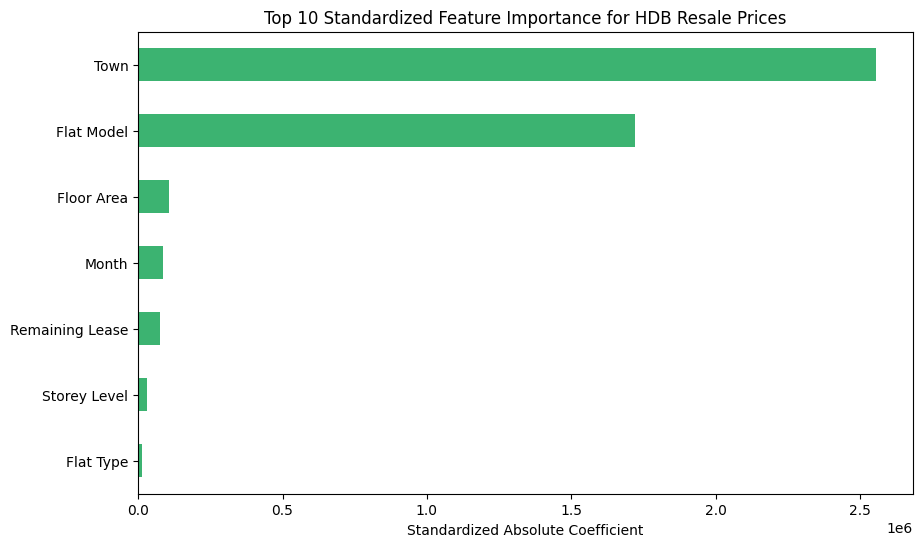

In [21]:
agg_features_series = pd.Series(agg_features)
agg_features_series = agg_features_series.abs().sort_values(ascending=False)

plt.figure(figsize=(10,6))
agg_features_series.head(10).plot(kind='barh', color='mediumseagreen')
plt.gca().invert_yaxis()
plt.title("Top 10 Standardized Feature Importance for HDB Resale Prices")
plt.xlabel("Standardized Absolute Coefficient")
plt.show()

## Checking for model performance

In [22]:
y_pred = model.predict(X_test)
# Create a comparison dataframe
comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
}).reset_index(drop=True)

# Add a column for the difference (Error)
comparison_df['Difference'] = comparison_df['Predicted'] - comparison_df['Actual']

# Display the top 5
print(comparison_df.head(5))
print()
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

     Actual      Predicted    Difference
0  745000.0  731566.598934 -13433.401066
1  808000.0  782274.853889 -25725.146111
2  608800.0  637095.381535  28295.381535
3  440000.0  519950.761281  79950.761281
4  420000.0  473012.818811  53012.818811

MAE: 52213.58788014606
R2: 0.868129420554007
